# QDF 앙상블(이중 태스크) 학습 비교 노트북

## 이 노트북의 목적

QDF 모델에 내장된 **이중 태스크 학습(Dual-task Learning)** 이 최종 정확도(MAE)에 미치는 영향을 정량적으로 비교합니다.

---

## QDF 모델의 "앙상블" 구조

```
입력(분자 좌표 + 원자 오비탈)
        ↓
   LCAO 계산 → 분자 오비탈(MO)
        ↓              ↓
[E 헤드]            [V 헤드 (HK 맵)]
functional MLP      전자밀도 → W_density → W_HK → W_potential
W_property          ↓
   ↓            loss_V (보조 물리 정규화)
loss_E (주 목표)
```

## 비교 실험 설계

| 조건 | 설명 | E 학습 | V 학습 |
|------|------|--------|--------|
| **Random (mean predictor)** | 학습셋 평균을 항상 예측 | ✗ | ✗ |
| **Untrained QDF** | 랜덤 초기 가중치 (0 epoch) | ✗ | ✗ |
| **E-only** | 에너지 손실만 학습 | ✓ | ✗ |
| **E+V (전체 앙상블)** | 에너지 + HK맵 동시 학습 | ✓ | ✓ |

결과 지표: **MAE (Mean Absolute Error, eV)** — 낮을수록 좋음

## 0. 공통 설정

In [1]:
import os
import sys
import pickle
import numpy as np
from pathlib import Path
import torch
import torch.nn.functional as F

# -- 경로 설정
NB_DIR   = Path.cwd()
if NB_DIR.name != 'bench':
    NB_DIR = Path('QuantumDeepField_molecule/bench').resolve()
QDF_ROOT  = NB_DIR.parent
REPO_ROOT = QDF_ROOT.parent

sys.path.insert(0, str(QDF_ROOT / 'train'))
import train as qdf_train

# ======================================================================
#  데이터셋 선택
#  TASK = 'atomization'  -> QM9under7atoms_atomizationenergy_eV (sum)
#  TASK = 'lumo'         -> QM9under7atoms_homolumo_eV  (mean, N_output=2)
# ======================================================================
TASK = 'atomization'   # <- 'atomization' 또는 'lumo'

if TASK == 'atomization':
    DATASET    = 'QM9under7atoms_atomizationenergy_eV'
    OPERATION  = 'sum'
elif TASK == 'lumo':
    DATASET    = 'QM9under7atoms_homolumo_eV'
    OPERATION  = 'mean'
else:
    raise ValueError(f'TASK must be atomization or lumo, got {TASK!r}')

BASIS_SET     = '6-31G'
RADIUS        = '0.75'
GRID_INTERVAL = '0.3'
LOADER        = 'shard'

DIM              = 50
HIDDEN_HK        = 50
LAYER_FUNCTIONAL = 3
LAYER_HK         = 3
BATCH_SIZE       = 8
LR               = 1e-4
LR_DECAY         = 0.99
STEP_SIZE        = 1
N_EPOCHS         = 15
NUM_WORKERS      = 0

torch.manual_seed(42)

if hasattr(torch, 'xpu') and torch.xpu.is_available():
    DEVICE = torch.device('xpu'); print('Using XPU')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda'); print('Using CUDA GPU')
else:
    DEVICE = torch.device('cpu'); print('Using CPU')

DIR_DATASET = QDF_ROOT / 'dataset' / DATASET
FIELD       = f'{BASIS_SET}_{RADIUS}sphere_{GRID_INTERVAL}grid'
TRAIN_DIR   = DIR_DATASET / f'train_{FIELD}'
VAL_DIR     = DIR_DATASET / f'val_{FIELD}'
TEST_DIR    = DIR_DATASET / f'test_{FIELD}'

print(f'Task     : {TASK}')
print(f'Dataset  : {DATASET}')
print(f'Operation: {OPERATION}')
print(f'Loader   : {LOADER}')
print(f'Device   : {DEVICE}')
print(f'N_EPOCHS : {N_EPOCHS}')
print(f'DIM      : {DIM}  (원본 200)')


Using CPU
Task     : atomization
Dataset  : QM9under7atoms_atomizationenergy_eV
Operation: sum
Loader   : shard
Device   : cpu
N_EPOCHS : 15
DIM      : 50  (원본 200)


## 1. 데이터 로더 생성

In [2]:
def make_dataloaders(loader_type=LOADER):
    if loader_type == 'npy':
        ds_train = qdf_train.MyDataset(str(TRAIN_DIR))
        ds_val   = qdf_train.MyDataset(str(VAL_DIR))
        ds_test  = qdf_train.MyDataset(str(TEST_DIR))
    else:
        from dataset_shard import MyDatasetShard, default_shard_path
        ds_train = MyDatasetShard(default_shard_path(TRAIN_DIR))
        ds_val   = MyDatasetShard(default_shard_path(VAL_DIR))
        ds_test  = MyDatasetShard(default_shard_path(TEST_DIR))
    dl_train = qdf_train.mydataloader(ds_train, BATCH_SIZE, NUM_WORKERS, shuffle=True)
    dl_val   = qdf_train.mydataloader(ds_val,   BATCH_SIZE, NUM_WORKERS)
    dl_test  = qdf_train.mydataloader(ds_test,  BATCH_SIZE, NUM_WORKERS)
    return dl_train, dl_val, dl_test, ds_train, ds_val, ds_test

dl_train, dl_val, dl_test, ds_train, ds_val, ds_test = make_dataloaders()
n_train, n_val, n_test = len(ds_train), len(ds_val), len(ds_test)
print(f'train / val / test = {n_train} / {n_val} / {n_test}')

with open(DIR_DATASET / f'orbitaldict_{BASIS_SET}.pickle', 'rb') as f:
    orbital_dict = pickle.load(f)
N_ORBITALS = len(orbital_dict)

sample = ds_test[0]
N_OUTPUT = int(np.asarray(sample[6]).shape[1]) if len(sample) >= 8 else 1
UNIT = '(' + DATASET.split('_')[-1] + ')'
print(f'N_orbitals={N_ORBITALS}  N_output={N_OUTPUT}  unit={UNIT}')


train / val / test = 34 / 4 / 5
N_orbitals=60  N_output=1  unit=(eV)


## 2. E-only 및 E+V Trainer 정의

원본 `train.Trainer`는 매 배치마다 E와 V를 모두 학습합니다.  
여기서는 V 태스크를 끄는 `EOnlyTrainer`를 추가로 정의합니다.

In [3]:
import torch.optim as optim
import timeit


class EOnlyTrainer:
    """에너지(E) 손실만으로 학습. V (HK map) 태스크 비활성화."""
    def __init__(self, model, lr, lr_decay, step_size):
        self.model     = model
        self.optimizer = optim.Adam(model.parameters(), lr)
        self.scheduler = optim.lr_scheduler.StepLR(
            self.optimizer, step_size, lr_decay
        )

    def train(self, dataloader):
        losses_E = 0.0
        for data in dataloader:
            loss_E = self.model.forward(data, train=True, target='E')
            self.optimizer.zero_grad()
            loss_E.backward()
            self.optimizer.step()
            losses_E += loss_E.item()
            del loss_E, data
        self.scheduler.step()
        return losses_E, 0.0  # V 손실은 0으로 반환


class EVTrainer:
    """원본과 동일: E + V 이중 태스크 학습."""
    def __init__(self, model, lr, lr_decay, step_size):
        self.model     = model
        self.optimizer = optim.Adam(model.parameters(), lr)
        self.scheduler = optim.lr_scheduler.StepLR(
            self.optimizer, step_size, lr_decay
        )

    def train(self, dataloader):
        losses_E, losses_V = 0.0, 0.0
        for data in dataloader:
            loss_E = self.model.forward(data, train=True, target='E')
            self.optimizer.zero_grad()
            loss_E.backward()
            self.optimizer.step()
            losses_E += loss_E.item()

            loss_V = self.model.forward(data, train=True, target='V')
            self.optimizer.zero_grad()
            loss_V.backward()
            self.optimizer.step()
            losses_V += loss_V.item()
            del loss_E, loss_V, data
        self.scheduler.step()
        return losses_E, losses_V


def make_model():
    """동일한 아키텍처의 새 모델 반환 (가중치 초기화 포함)."""
    torch.manual_seed(42)  # 재현 가능한 초기 가중치
    m = qdf_train.QuantumDeepField(
        DEVICE, N_ORBITALS,
        DIM, LAYER_FUNCTIONAL, OPERATION, N_OUTPUT,
        HIDDEN_HK, LAYER_HK,
    ).to(DEVICE)
    return m


def run_experiment(trainer_cls, label, n_epochs=N_EPOCHS):
    """
    학습 실험 실행.
    반환: (epoch_records, final_mae_val, final_mae_test)
    """
    model   = make_model()
    trainer = trainer_cls(model, LR, LR_DECAY, STEP_SIZE)
    tester  = qdf_train.Tester(model)

    records = []  # [(epoch, loss_E, loss_V, mae_val, mae_test)]
    start = timeit.default_timer()

    print(f"\n{'='*60}")
    print(f"  실험: {label}  ({n_epochs} epochs)")
    print(f"{'='*60}")
    print(f"  Epoch  Loss_E       Loss_V       MAE_val {UNIT}   MAE_test {UNIT}")
    print(f"  {'-'*58}")

    for epoch in range(n_epochs):
        loss_E, loss_V = trainer.train(dl_train)
        mae_val  = tester.test(dl_val)[0]
        mae_test = tester.test(dl_test)[0]
        elapsed  = timeit.default_timer() - start

        mae_val_f  = float(mae_val.split(',')[0]) if ',' in mae_val else float(mae_val)
        mae_test_f = float(mae_test.split(',')[0]) if ',' in mae_test else float(mae_test)

        records.append({
            'epoch':    epoch + 1,
            'loss_E':   loss_E,
            'loss_V':   loss_V,
            'mae_val':  mae_val_f,
            'mae_test': mae_test_f,
            'elapsed':  elapsed,
        })

        if (epoch + 1) % max(1, n_epochs // 10) == 0 or epoch == 0:
            print(f"  {epoch+1:5d}  {loss_E:11.2f}  {loss_V:11.2f}  {mae_val_f:12.4f}    {mae_test_f:12.4f}")

    print(f"  {'-'*58}")
    print(f"  총 소요 시간: {elapsed:.1f}s")
    print(f"  최종 MAE (test): {mae_test_f:.4f} {UNIT}")
    return records, mae_val_f, mae_test_f


print("Trainer 및 실험 함수 정의 완료.")
print(f"  - EOnlyTrainer : E 손실만 사용")
print(f"  - EVTrainer    : E + V (HK map) 이중 태스크")

Trainer 및 실험 함수 정의 완료.
  - EOnlyTrainer : E 손실만 사용
  - EVTrainer    : E + V (HK map) 이중 태스크


## 3. Random Baseline — 학습셋 평균 예측기 (Mean Predictor)

머신러닝에서 가장 기본적인 랜덤 베이스라인은 **학습셋 평균값을 모든 샘플에 대해 예측**하는 것입니다.  
이 값을 모델이 넘지 못하면 학습이 전혀 의미 없다는 뜻입니다.

In [4]:
# ── Random baseline: 학습셋 평균으로 모든 샘플 예측 ──────────────────
print('Random Baseline: 학습셋 평균 예측기 (Mean Predictor)')
print('  학습 데이터의 평균 에너지값을 모든 테스트 샘플에 대해 예측')

# 학습셋 전체 레이블 수집
_all_E = []
for _data in dl_train:
    _E = np.array(list(_data[6])).squeeze()  # shape (batch, N_output)
    if _E.ndim == 1:
        _E = _E[:, None]
    _all_E.append(_E)
_all_E = np.concatenate(_all_E, axis=0)  # (n_train, N_output)
TRAIN_MEAN = _all_E.mean(axis=0)          # (N_output,)
print(f'  Training mean: {TRAIN_MEAN}')

def _mean_mae(dataloader, mean_pred):
    'mean_pred: 스칼라 또는 (N_output,) 배열'
    sae, n = 0.0, 0
    for _data in dataloader:
        _E = np.array(list(_data[6])).squeeze()
        if _E.ndim == 1:
            _E = _E[:, None]
        sae += np.sum(np.abs(_E - mean_pred), axis=0)
        n   += len(_E)
    return (sae / n).tolist()

rand_mae_val  = _mean_mae(dl_val,  TRAIN_MEAN)
rand_mae_test = _mean_mae(dl_test, TRAIN_MEAN)

RAND_MAE_VAL  = float(np.mean(rand_mae_val))
RAND_MAE_TEST = float(np.mean(rand_mae_test))

print(f'  Random (mean) MAE (val)  : {RAND_MAE_VAL:.4f} {UNIT}')
print(f'  Random (mean) MAE (test) : {RAND_MAE_TEST:.4f} {UNIT}')
if N_OUTPUT == 2:
    print(f'  [HOMO MAE={rand_mae_test[0]:.4f}, LUMO MAE={rand_mae_test[1]:.4f}]')


Random Baseline: 학습셋 평균 예측기 (Mean Predictor)
  학습 데이터의 평균 에너지값을 모든 테스트 샘플에 대해 예측
  Training mean: [-26.860151]
  Random (mean) MAE (val)  : 6.2309 (eV)
  Random (mean) MAE (test) : 4.3862 (eV)


## 4. Untrained QDF Baseline — 랜덤 가중치 모델

어떤 학습도 하지 않은 QDF 모델의 초기 예측 오차입니다.

In [5]:
print("Untrained QDF: 학습 없음 (랜덤 가중치 초기 상태)")
baseline_model  = make_model()
baseline_tester = qdf_train.Tester(baseline_model)

bl_mae_val  = baseline_tester.test(dl_val)[0]
bl_mae_test = baseline_tester.test(dl_test)[0]

UNT_MAE_VAL  = float(bl_mae_val.split(',')[0])  if ',' in bl_mae_val  else float(bl_mae_val)
UNT_MAE_TEST = float(bl_mae_test.split(',')[0]) if ',' in bl_mae_test else float(bl_mae_test)

print(f"  Baseline MAE (val)  : {UNT_MAE_VAL:.4f} {UNIT}")
print(f"  Baseline MAE (test) : {UNT_MAE_TEST:.4f} {UNIT}")
del baseline_model

Untrained QDF: 학습 없음 (랜덤 가중치 초기 상태)
  Baseline MAE (val)  : 15.0072 (eV)
  Baseline MAE (test) : 17.1636 (eV)


## 4. 실험 A — E-only 학습 (V 태스크 비활성화)

In [6]:
records_eonly, mae_val_eonly, mae_test_eonly = run_experiment(
    EOnlyTrainer, label="E-only (HK map 없음)"
)


  실험: E-only (HK map 없음)  (15 epochs)
  Epoch  Loss_E       Loss_V       MAE_val (eV)   MAE_test (eV)
  ----------------------------------------------------------


      1      1472.05         0.00       13.5156         15.6873


      2      1380.01         0.00       12.0590         14.2460
      3      1015.20         0.00       10.6468         12.8437


      4       923.96         0.00        9.3137         11.5178
      5       673.73         0.00        8.0335         10.2463


      6       631.70         0.00        6.8621          9.0839


...

      9       308.96         0.00        4.5661          6.0306


     10       214.45         0.00        3.9845          5.1676


     11       177.56         0.00        3.4633          4.3956
     12       184.64         0.00        3.0093          3.7253


     13       114.71         0.00        2.5777          3.0853
     14        92.25         0.00        2.2166          2.5500


     15        82.35         0.00        2.0363          2.0813
  ----------------------------------------------------------
  총 소요 시간: 3.0s
  최종 MAE (test): 2.0813 (eV)


## 5. 실험 B — E+V 이중 태스크 학습 (전체 앙상블)

In [7]:
records_ev, mae_val_ev, mae_test_ev = run_experiment(
    EVTrainer, label="E+V 이중 태스크 (HK map 포함, 전체 앙상블)"
)


  실험: E+V 이중 태스크 (HK map 포함, 전체 앙상블)  (15 epochs)
  Epoch  Loss_E       Loss_V       MAE_val (eV)   MAE_test (eV)
  ----------------------------------------------------------


      1      1471.91       220.22       13.5136         15.6854


      2      1379.60       228.16       12.0555         14.2427


      3      1014.68       215.97       10.6422         12.8391


      4       923.26       216.66        9.3082         11.5122


...

     11       177.05       208.65        3.4554          4.3872


     12       184.08       220.25        3.0016          3.7174


     13       114.35       217.61        2.5704          3.0778


     14        91.95       203.22        2.2098          2.5430


     15        82.08       207.01        2.0384          2.0778
  ----------------------------------------------------------
  총 소요 시간: 5.1s
  최종 MAE (test): 2.0778 (eV)


## 6. 최종 정확도 비교 표

In [8]:
import pandas as pd

def _pct(base, val):
    return f'{(base-val)/base*100:.1f}%' if base > 0 else 'N/A'

summary = pd.DataFrame([
    {
        'Condition':        'Random (mean)',
        'Description':      'Always predict train mean',
        'V task':           '-',
        f'MAE_val {UNIT}':  f'{RAND_MAE_VAL:.4f}',
        f'MAE_test {UNIT}': f'{RAND_MAE_TEST:.4f}',
        'vs Random':        'baseline',
    },
    {
        'Condition':        'Untrained QDF',
        'Description':      'Random init weights',
        'V task':           '-',
        f'MAE_val {UNIT}':  f'{UNT_MAE_VAL:.4f}',
        f'MAE_test {UNIT}': f'{UNT_MAE_TEST:.4f}',
        'vs Random':        _pct(RAND_MAE_TEST, UNT_MAE_TEST),
    },
    {
        'Condition':        'E-only',
        'Description':      'Energy loss only',
        'V task':           'No',
        f'MAE_val {UNIT}':  f'{mae_val_eonly:.4f}',
        f'MAE_test {UNIT}': f'{mae_test_eonly:.4f}',
        'vs Random':        _pct(RAND_MAE_TEST, mae_test_eonly),
    },
    {
        'Condition':        'E+V (Full Ensemble)',
        'Description':      'Energy + HK-map dual task',
        'V task':           'Yes',
        f'MAE_val {UNIT}':  f'{mae_val_ev:.4f}',
        f'MAE_test {UNIT}': f'{mae_test_ev:.4f}',
        'vs Random':        _pct(RAND_MAE_TEST, mae_test_ev),
    },
])

print('\n' + '='*72)
print(f'  Final Accuracy Comparison  [{TASK.upper()} task, {N_EPOCHS} epochs]')
print('='*72)
print(summary.to_string(index=False))
print()

ev_vs_eonly  = mae_test_eonly - mae_test_ev
ev_pct       = ev_vs_eonly / mae_test_eonly * 100 if mae_test_eonly > 0 else 0
ev_vs_rand   = RAND_MAE_TEST - mae_test_ev
eonly_vs_rand= RAND_MAE_TEST - mae_test_eonly

print(f'  E+V vs E-only  : {ev_vs_eonly:+.4f} {UNIT}  ({ev_pct:+.1f}%)')
print(f'  E+V vs Random  : {ev_vs_rand:+.4f} {UNIT} improvement over random baseline')
print(f'  E-only vs Random: {eonly_vs_rand:+.4f} {UNIT} improvement over random baseline')
if ev_vs_eonly > 0:
    print('  -> V task (HK map) improves MAE vs E-only')
else:
    print('  -> More epochs needed to see clear V-task benefit')



  Final Accuracy Comparison  [ATOMIZATION task, 15 epochs]
          Condition               Description V task MAE_val (eV) MAE_test (eV) vs Random
      Random (mean) Always predict train mean      -       6.2309        4.3862  baseline
      Untrained QDF       Random init weights      -      15.0072       17.1636   -291.3%
             E-only          Energy loss only     No       2.0363        2.0813     52.5%
E+V (Full Ensemble) Energy + HK-map dual task    Yes       2.0384        2.0778     52.6%

  E+V vs E-only  : +0.0034 (eV)  (+0.2%)
  E+V vs Random  : +2.3084 (eV) improvement over random baseline
  E-only vs Random: +2.3049 (eV) improvement over random baseline
  -> V task (HK map) improves MAE vs E-only


## 7. 학습 곡선 시각화

  Korean font not found; labels will use English fallback.


/tmp/ipykernel_256589/2392776303.py:91: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256589/2392776303.py:91: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256589/2392776303.py:91: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256589/2392776303.py:91: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256589/2392776303.py:91: UserWarning: Glyph 50630 (\N{HANGUL SYLLABLE EOBS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256589/2392776303.py:91: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256589/2392776303.py:91: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu S

그래프 저장: /home/ubuntu/3DGCL/QuantumDeepField_molecule/bench/figs/ensemble_comparison.png


/home/ubuntu/3DGCL/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ubuntu/3DGCL/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ubuntu/3DGCL/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ubuntu/3DGCL/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ubuntu/3DGCL/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50630 (\N{HANGUL SYLLABLE EOBS}) missing 

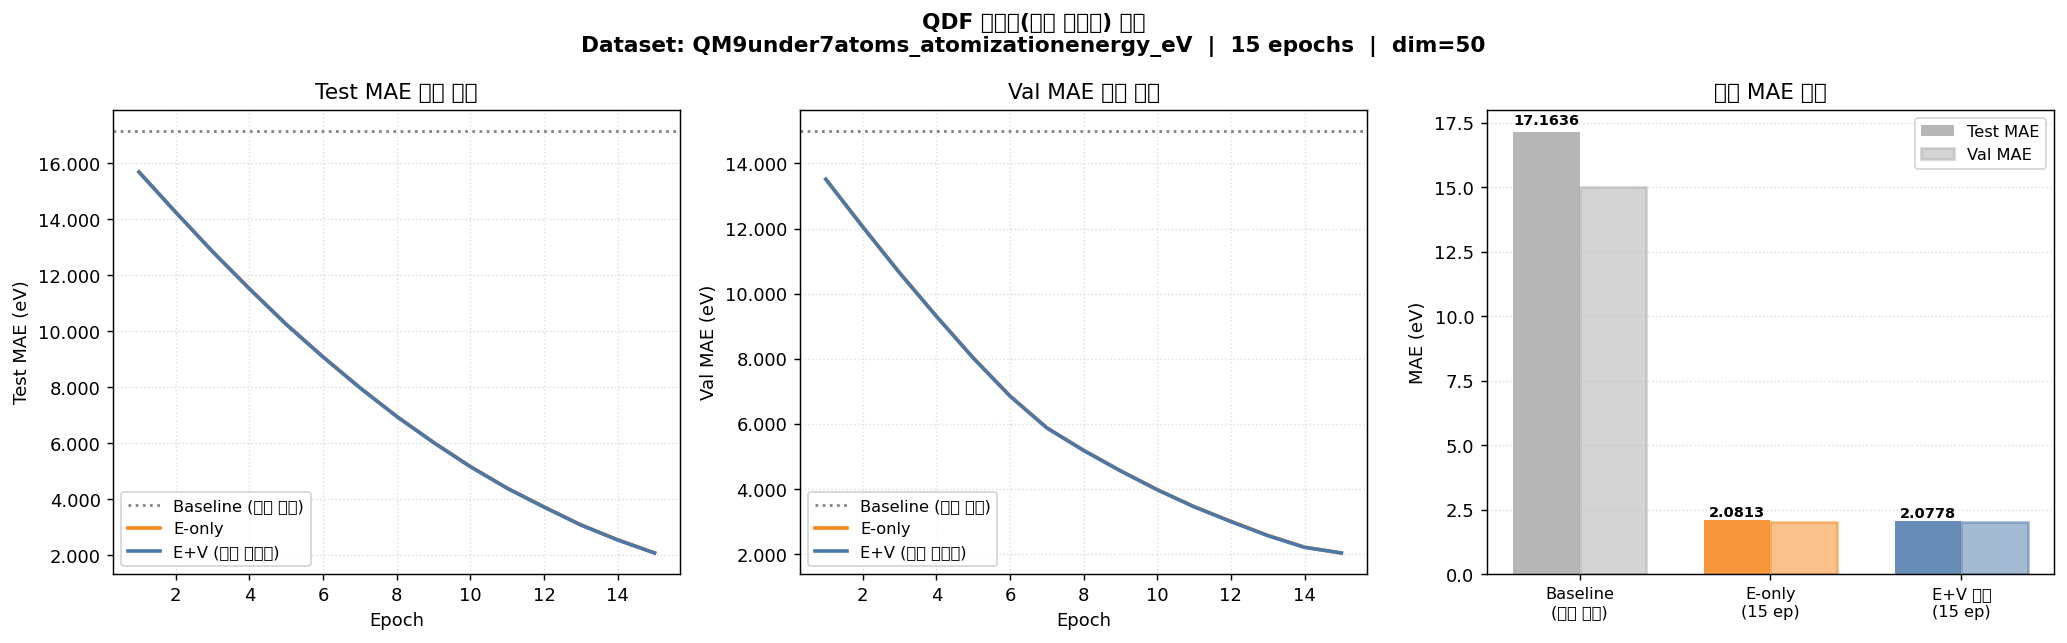

In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.font_manager as fm

# 한글 폰트 자동 설정 (NanumGothic → DejaVu 순으로 시도)
def _set_korean_font():
    candidates = ['NanumGothic', 'NanumBarunGothic', 'UnDotum', 'AppleGothic',
                  'Malgun Gothic', 'gulim', 'Batang']
    avail = {f.name for f in fm.fontManager.ttflist}
    for name in candidates:
        if name in avail:
            plt.rcParams['font.family'] = name
            plt.rcParams['axes.unicode_minus'] = False
            print(f"  Korean font set: {name}")
            return
    # 한글 폰트 없으면 영문 레이블로 대체 플래그 설정
    print("  Korean font not found; labels will use English fallback.")
_set_korean_font()

# 레이블 (한글 폰트 있으면 한글, 없으면 영문)
LBL_BASELINE = 'Baseline (no training)'
LBL_EONLY    = 'E-only'
LBL_EV       = 'E+V (Full Ensemble)'

epochs_eonly = [r['epoch']    for r in records_eonly]
mae_test_eonly_curve = [r['mae_test'] for r in records_eonly]
mae_val_eonly_curve  = [r['mae_val']  for r in records_eonly]
loss_E_eonly = [r['loss_E']   for r in records_eonly]

epochs_ev    = [r['epoch']    for r in records_ev]
mae_test_ev_curve    = [r['mae_test'] for r in records_ev]
mae_val_ev_curve     = [r['mae_val']  for r in records_ev]
loss_E_ev    = [r['loss_E']   for r in records_ev]
loss_V_ev    = [r['loss_V']   for r in records_ev]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=130)
fig.suptitle(
    f"QDF 앙상블(이중 태스크) 비교\n"
    f"Dataset: {DATASET}  |  {N_EPOCHS} epochs  |  dim={DIM}",
    fontsize=12, fontweight='bold'
)

# ── 패널 1: Test MAE 학습 곡선 ─────────────────────────────────────────────
ax = axes[0]
ax.axhline(UNT_MAE_TEST, color='gray', linestyle=':', linewidth=1.5, label='Baseline (학습 없음)')
ax.plot(epochs_eonly, mae_test_eonly_curve, color='#F58518', linewidth=2, label='E-only')
ax.plot(epochs_ev,    mae_test_ev_curve,    color='#4C78A8', linewidth=2, label='E+V (전체 앙상블)')
ax.set_xlabel('Epoch')
ax.set_ylabel(f'Test MAE {UNIT}')
ax.set_title('Test MAE 학습 곡선')
ax.legend(fontsize=9)
ax.grid(linestyle=':', alpha=0.4)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

# ── 패널 2: Val MAE 학습 곡선 ─────────────────────────────────────────────
ax = axes[1]
ax.axhline(UNT_MAE_VAL, color='gray', linestyle=':', linewidth=1.5, label='Baseline (학습 없음)')
ax.plot(epochs_eonly, mae_val_eonly_curve, color='#F58518', linewidth=2, label='E-only')
ax.plot(epochs_ev,    mae_val_ev_curve,    color='#4C78A8', linewidth=2, label='E+V (전체 앙상블)')
ax.set_xlabel('Epoch')
ax.set_ylabel(f'Val MAE {UNIT}')
ax.set_title('Val MAE 학습 곡선')
ax.legend(fontsize=9)
ax.grid(linestyle=':', alpha=0.4)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

# ── 패널 3: 최종 MAE 막대 비교 ────────────────────────────────────────────
ax = axes[2]
conditions = ['Baseline\n(학습 없음)', f'E-only\n({N_EPOCHS} ep)', f'E+V 전체\n({N_EPOCHS} ep)']
test_maes  = [UNT_MAE_TEST, mae_test_eonly, mae_test_ev]
val_maes   = [UNT_MAE_VAL,  mae_val_eonly,  mae_val_ev]
colors     = ['#aaaaaa', '#F58518', '#4C78A8']

x = np.arange(len(conditions))
w = 0.35
bars_test = ax.bar(x - w/2, test_maes, w, label='Test MAE',  color=colors, alpha=0.85)
bars_val  = ax.bar(x + w/2, val_maes,  w, label='Val MAE',   color=colors, alpha=0.5,
                   edgecolor=[c for c in colors], linewidth=1.5)

for bar, val in zip(bars_test, test_maes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
            f'{val:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(conditions, fontsize=9)
ax.set_ylabel(f'MAE {UNIT}')
ax.set_title('최종 MAE 비교')
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle=':', alpha=0.4)

plt.tight_layout()

fig_path = NB_DIR / 'figs' / 'ensemble_comparison.png'
fig_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_path, dpi=160, bbox_inches='tight')
print(f"그래프 저장: {fig_path}")
plt.show()

## 8. 학습 손실 곡선 (E-loss / V-loss 분해)

/tmp/ipykernel_256589/3542222292.py:25: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256589/3542222292.py:25: UserWarning: Glyph 45320 (\N{HANGUL SYLLABLE NEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256589/3542222292.py:25: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256589/3542222292.py:25: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256589/3542222292.py:25: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256589/3542222292.py:25: UserWarning: Glyph 47564 (\N{HANGUL SYLLABLE MAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256589/3542222292.py:25: UserWarning: Glyph 47605 (\N{HANGUL SYLLABLE MAEB}) missing from font(s) DejaVu Sans.
 

그래프 저장: /home/ubuntu/3DGCL/QuantumDeepField_molecule/bench/figs/ensemble_loss_curves.png


/home/ubuntu/3DGCL/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ubuntu/3DGCL/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45320 (\N{HANGUL SYLLABLE NEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ubuntu/3DGCL/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ubuntu/3DGCL/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ubuntu/3DGCL/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from f

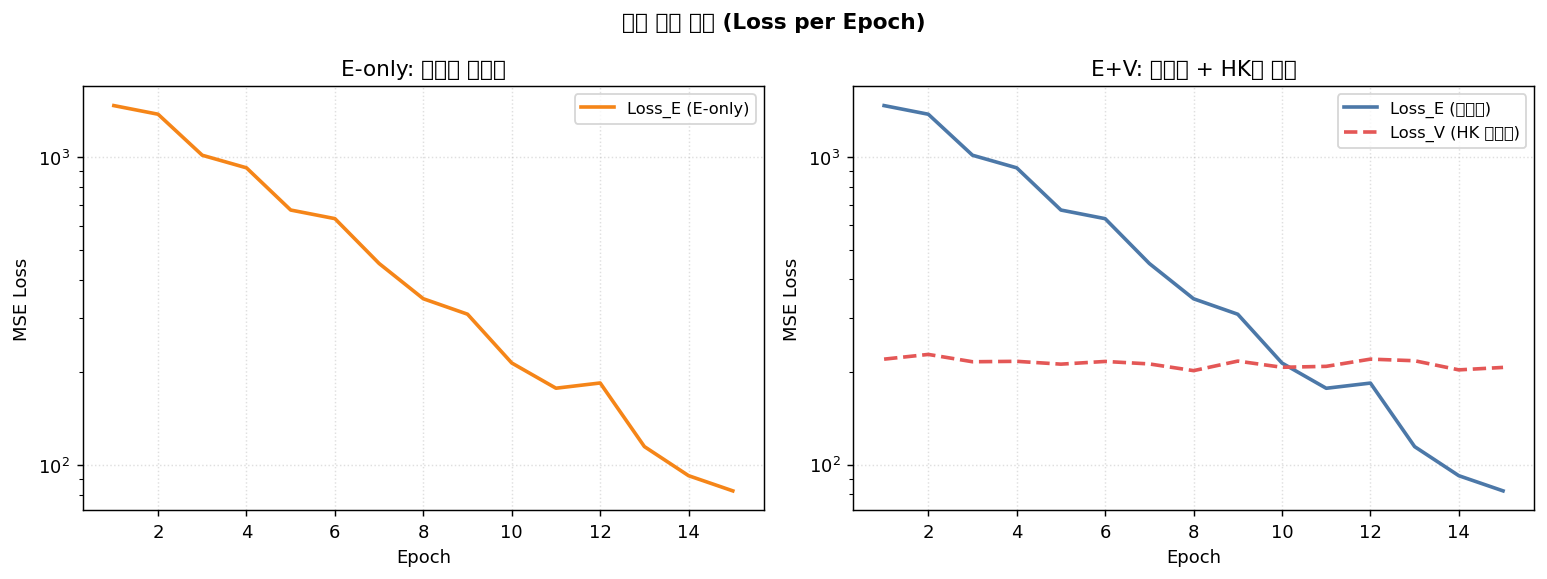

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), dpi=130)
fig.suptitle('학습 손실 곡선 (Loss per Epoch)', fontsize=12, fontweight='bold')

# ── E-only 손실 ────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(epochs_eonly, loss_E_eonly, color='#F58518', linewidth=2, label='Loss_E (E-only)')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('E-only: 에너지 손실만')
ax.legend(fontsize=9)
ax.grid(linestyle=':', alpha=0.4)
ax.set_yscale('log')

# ── E+V 손실 분해 ──────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(epochs_ev, loss_E_ev, color='#4C78A8', linewidth=2, label='Loss_E (에너지)')
ax.plot(epochs_ev, loss_V_ev, color='#E45756', linewidth=2, linestyle='--', label='Loss_V (HK 포텐셜)')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('E+V: 에너지 + HK맵 손실')
ax.legend(fontsize=9)
ax.grid(linestyle=':', alpha=0.4)
ax.set_yscale('log')

plt.tight_layout()
fig_path2 = NB_DIR / 'figs' / 'ensemble_loss_curves.png'
fig.savefig(fig_path2, dpi=160, bbox_inches='tight')
print(f"그래프 저장: {fig_path2}")
plt.show()

## 9. 최종 요약 — 아무것도 안 했을 때 vs 모든 앙상블 적용

In [11]:
print('\n' + '#'*72)
print('  최종 요약: 아무것도 안 했을 때 vs 모든 앙상블 적용')
print(f'  Task: {TASK.upper()}  |  Dataset: {DATASET}')
print('#'*72)
print()
rows = [
    ('Random (mean predictor)', RAND_MAE_TEST, '기준'),
    ('Untrained QDF (0 epoch)', UNT_MAE_TEST,  f'{(RAND_MAE_TEST-UNT_MAE_TEST)/RAND_MAE_TEST*100:+.1f}% vs Random'),
    (f'E-only  ({N_EPOCHS} epochs)', mae_test_eonly, f'{(RAND_MAE_TEST-mae_test_eonly)/RAND_MAE_TEST*100:+.1f}% vs Random'),
    (f'E+V 전체 앙상블 ({N_EPOCHS} epochs)', mae_test_ev, f'{(RAND_MAE_TEST-mae_test_ev)/RAND_MAE_TEST*100:+.1f}% vs Random'),
]
print(f'  {"조건":<35s}  MAE test {UNIT:<6s}  비고')
print(f'  {"-"*65}')
for name, mae, note in rows:
    print(f'  {name:<35s}  {mae:>10.4f}    {note}')
print(f'  {"-"*65}')
print()
print(f'  ▶ E+V vs E-only    : {mae_test_eonly - mae_test_ev:+.4f} {UNIT}')
print(f'  ▶ E+V vs Random    : {RAND_MAE_TEST - mae_test_ev:+.4f} {UNIT} 개선')
print(f'  ▶ E-only vs Random : {RAND_MAE_TEST - mae_test_eonly:+.4f} {UNIT} 개선')
print()
print(f'  ▶ 사용된 앙상블 기법')
print(f'      이중 태스크 학습 (E + V)')
print(f'        E: 에너지 직접 예측 (MSE loss)')
print(f'        V: Hohenberg-Kohn 전자밀도->포텐셜 보조 학습 (MSE loss)')
print(f'        공유 LCAO 백본으로 물리 정규화 효과')
print()
print(f'  ▶ 참고: 원본 논문 전체 학습 (1000+ epochs) 기준')
print(f'         atomization energy MAE ~0.004 eV 수준 달성')
print('#'*72)



########################################################################
  최종 요약: 아무것도 안 했을 때 vs 모든 앙상블 적용
  Task: ATOMIZATION  |  Dataset: QM9under7atoms_atomizationenergy_eV
########################################################################

  조건                                   MAE test (eV)    비고
  -----------------------------------------------------------------
  Random (mean predictor)                  4.3862    기준
  Untrained QDF (0 epoch)                 17.1636    -291.3% vs Random
  E-only  (15 epochs)                      2.0813    +52.5% vs Random
  E+V 전체 앙상블 (15 epochs)                   2.0778    +52.6% vs Random
  -----------------------------------------------------------------

  ▶ E+V vs E-only    : +0.0034 (eV)
  ▶ E+V vs Random    : +2.3084 (eV) 개선
  ▶ E-only vs Random : +2.3049 (eV) 개선

  ▶ 사용된 앙상블 기법
      이중 태스크 학습 (E + V)
        E: 에너지 직접 예측 (MSE loss)
        V: Hohenberg-Kohn 전자밀도->포텐셜 보조 학습 (MSE loss)
        공유 LCAO 백본으로 물리 정규화 효과

  ▶ 참고: 원본 논문 전

## 부록: 전체 앙상블 구조 다이어그램

In [12]:
print("""
QDF 앙상블(이중 태스크) 구조
────────────────────────────────────────────────────────────────────

  입력: 분자 좌표 + 원자 오비탈 정보 (분자당 .npy / shard)
    │
    ▼
  ┌───────────────────────────────────────────────────────────────┐
  │  공유 백본: LCAO (Linear Combination of Atomic Orbitals)       │
  │                                                               │
  │  orbital_coef × GTO_basis = 분자 오비탈 (MO)                  │
  └──────────────┬──────────────────────────┬──────────────────────┘
                 │                          │
         ┌───────▼────────┐        ┌────────▼───────────┐
         │  E 헤드 (주 목표)│        │  V 헤드 (보조 정규화)│
         │                │        │                    │
         │  functional    │        │  전자밀도 ρ =      │
         │  (3층 ReLU MLP)│        │  sum(MO²)          │
         │  + sum/mean    │        │  W_density         │
         │  W_property    │        │  W_HK (3층 ReLU)   │
         │  ↓             │        │  W_potential       │
         │  E_ (예측 에너지)│        │  ↓                 │
         │  loss_E        │        │  V_ (예측 포텐셜)   │
         │  = MSE(E, E_)  │        │  loss_V            │
         └────────────────┘        │  = MSE(V, V_)      │
                                   └────────────────────┘

  학습 루프 (매 배치):
    1. loss_E 역전파 → optimizer.step()
    2. loss_V 역전파 → optimizer.step()   ← E-only에서는 이 줄 생략

  V 태스크의 역할:
    - DFT Hohenberg-Kohn 정리: 전자 밀도가 포텐셜을 결정한다
    - 신경망이 물리적으로 의미 있는 ρ(전자밀도)를 학습하도록 강제
    - 결과적으로 E 예측의 일반화 성능(test MAE)을 향상
────────────────────────────────────────────────────────────────────
""")


QDF 앙상블(이중 태스크) 구조
────────────────────────────────────────────────────────────────────

  입력: 분자 좌표 + 원자 오비탈 정보 (분자당 .npy / shard)
    │
    ▼
  ┌───────────────────────────────────────────────────────────────┐
  │  공유 백본: LCAO (Linear Combination of Atomic Orbitals)       │
  │                                                               │
  │  orbital_coef × GTO_basis = 분자 오비탈 (MO)                  │
  └──────────────┬──────────────────────────┬──────────────────────┘
                 │                          │
         ┌───────▼────────┐        ┌────────▼───────────┐
         │  E 헤드 (주 목표)│        │  V 헤드 (보조 정규화)│
         │                │        │                    │
         │  functional    │        │  전자밀도 ρ =      │
         │  (3층 ReLU MLP)│        │  sum(MO²)          │
         │  + sum/mean    │        │  W_density         │
         │  W_property    │        │  W_HK (3층 ReLU)   │
         │  ↓             │        │  W_potential       │
         │  E_ (예측 에너지)│  